# [LAB-10] 2-1. 로지스틱 회귀의 의미

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helper import *
from pandas import DataFrame
import numpy as np
from IPython.display import Markdown, display

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 및 전처리

1단원과 **동일한 데이터**를 사용한다.

- `iris_bin`은 붓꽃 데이터에서 구분이 어려운 **versicolor · virginica** 두 품종만 남긴 이진분류용 데이터(100건)이다.
- 종속변수 `Species`를 **0(versicolor) / 1(virginica)** 로 라벨링한다.
- 이번 단원은 꽃받침 길이(`Sepal_Length`) **하나**로 회귀계수 해석의 언어(오즈·로짓·오즈비)를 익힌다.

In [2]:
origin = load_data('iris_bin')

# 종속변수 라벨링 (versicolor = 0, virginica = 1)
df = my_prep.labeling(origin, columns=['Species'])

df.head()

📚 아이리스 데이터셋을 이진분류 예제용으로 종속변수의 종류를 2개로 변경한 데이터 (Kaggle의 데이터셋을 직접 수정함)

    field         description
--  ------------  ----------------------------
 0  Sepal_Length  꽃받침 길이
 1  Sepal_Width   꽃받침 너비
 2  Petal_Length  꽃잎 길이
 3  Petal_Width   꽃잎 너비
 4  Species       품종 (versicolor, virginica)

Species (2종): versicolor=0, virginica=1


,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,7.000,3.200,4.700,1.400,0
1,6.400,3.200,4.500,1.500,0
2,6.900,3.100,4.900,1.500,0
3,5.500,2.300,4.000,1.300,0
4,6.500,2.800,4.600,1.500,0


## #02. 회귀계수를 그대로 해석할 수 없는 이유

### 1. 단순로지스틱회귀 모형 적합

1단원에서 만든, 꽃받침 길이 하나로 적합한 단순로지스틱회귀 모형을 다시 적합한다.

In [3]:
data1 = df[['Sepal_Length', 'Species']]

fit1 = my_logit.fit_model(data1, y='Species', summary=True)

print(f"회귀계수(B) : {fit1.params['Sepal_Length']:.4f}")
print(f"절편        : {fit1.params['const']:.4f}")

                           Logit Regression Results                           
Dep. Variable:                Species   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.2026
Time:                        11:16:22   Log-Likelihood:                -55.273
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 1.162e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.5708      2.907     -4.325      0.000     -18.268      -6.873
Sepal_Length     2.0129      0.465      4.325      0.000       1.101       2.925
회귀계수(B) : 2.0129
절편        : -12.5708


### 2. "B = 2.0129" 는 무슨 뜻인가?

- 선형회귀라면 "$x$가 1 증가할 때 $y$가 2.0129 증가"로 읽으면 되지만,    
  로지스틱회귀에서 **"꽃받침 길이가 1cm 늘면 확률이 2.0129 증가"라고 읽으면 틀린다.**
  - 확률은 0~1 사이의 값이므로 2.0129만큼 증가할 수 없다.
  - 실제로 **확률의 증가폭은 $x$의 위치마다 다르다.** (S자 곡선의 기울기가 구간마다 다르기 때문)

In [4]:
# 1cm 늘려가며 예측 확률 '증가폭'을 비교
lengths = [5.0, 6.0, 7.0, 8.0]

# 예측값 생성
probs = my_logit.predict(fit1, DataFrame({'Sepal_Length': lengths}))['proba']

check = DataFrame({'Sepal_Length': lengths, '확률(P)': probs})
check['확률 증가폭'] = check['확률(P)'].diff()  # 직전 값 대비 확률의 증가량

check

,Sepal_Length,확률(P),확률 증가폭
0,5.000,0.075,NaN
1,6.000,0.379,0.304
2,7.000,0.820,0.441
3,8.000,0.972,0.151


> **확률의 증가폭이 구간마다 완전히 다르다.**
> 5→6cm 구간과 6→7cm 구간에서 늘어나는 확률의 양이 같지 않다.
> 즉 **"1cm 증가 = 확률 얼마 증가"라는 고정된 답이 존재하지 않는다.**
>
> 그렇다면 회귀계수 $B$는 **무엇이** 일정하게 증가한다는 뜻일까? → **오즈(Odds)**

## #03. 오즈(Odds)

### 1. 오즈의 정의

In [5]:
# 확률과 오즈의 대응 관계
p = np.array([0.1, 0.2, 0.5, 0.8, 0.9, 0.99])

odds_table = DataFrame({
    '확률(P)': p,
    '오즈(P/(1-P))': p / (1 - p)
})

odds_table

,확률(P),오즈(P/(1-P))
0,0.100,0.111
1,0.200,0.250
2,0.500,1.000
3,0.800,4.000
4,0.900,9.000
5,0.990,99.000


### 2. 오즈는 일정한 배율로 증가한다

앞에서 본 꽃받침 길이 5·6·7·8cm의 예측 확률을 **오즈로 바꿔서** 다시 비교해 보자.

In [6]:
check['오즈'] = check['확률(P)'] / (1 - check['확률(P)'])

# 직전 오즈 대비 몇 배가 되었는가 = 오즈의 '배율'
check['오즈 배율'] = check['오즈'] / check['오즈'].shift(1)

check

,Sepal_Length,확률(P),확률 증가폭,오즈,오즈 배율
0,5.000,0.075,NaN,0.082,NaN
1,6.000,0.379,0.304,0.611,7.485
2,7.000,0.820,0.441,4.571,7.485
3,8.000,0.972,0.151,34.214,7.485


> **확률의 증가폭은 들쭉날쭉했지만, 오즈의 배율은 항상 일정하다.**
> 꽃받침 길이가 1cm 늘어날 때마다 오즈는 **항상 같은 배수**만큼 커진다.
>
> 바로 이 **일정한 배율**이 회귀계수가 말하는 값이며, 이것을 **오즈비(Odds Ratio)** 라 한다.

## #04. 로짓(Logit)

### 1. 확률·오즈·로짓 비교

In [7]:
# 확률 / 오즈 / 로짓을 각각 그려서 비교 (실제 Sepal_Length 값 사용)
# 실제 관측된 꽃받침 길이를 x축으로 사용 (선을 매끄럽게 잇기 위해 정렬)
x_real = data1['Sepal_Length'].sort_values().values

p_real_df = my_logit.predict(fit1, DataFrame({'Sepal_Length': x_real}))
p_real = p_real_df['proba'].values

odds_real = p_real / (1 - p_real)     # 오즈
logit_real = np.log(odds_real)        # 로짓 = log(오즈)

print(f"확률(P) : {p_real[:5]} ... {p_real[-5:]}")
print(f"오즈     : {odds_real[:5]} ... {odds_real[-5:]}")
print(f"로짓     : {logit_real[:5]} ... {logit_real[-5:]}")

확률(P) : [0.0625357  0.0625357  0.07542828 0.07542828 0.09072162] ... [0.94924971 0.94924971 0.94924971 0.94924971 0.96548845]
오즈     : [0.06670729 0.06670729 0.08158186 0.08158186 0.0997732 ] ... [18.70432083 18.70432083 18.70432083 18.70432083 27.97580299]
로짓     : [-2.70744104 -2.70744104 -2.50614834 -2.50614834 -2.30485564] ... [2.92875456 2.92875456 2.92875456 2.92875456 3.33133996]


### 1. 확률·오즈·로짓 비교 결과 시각화

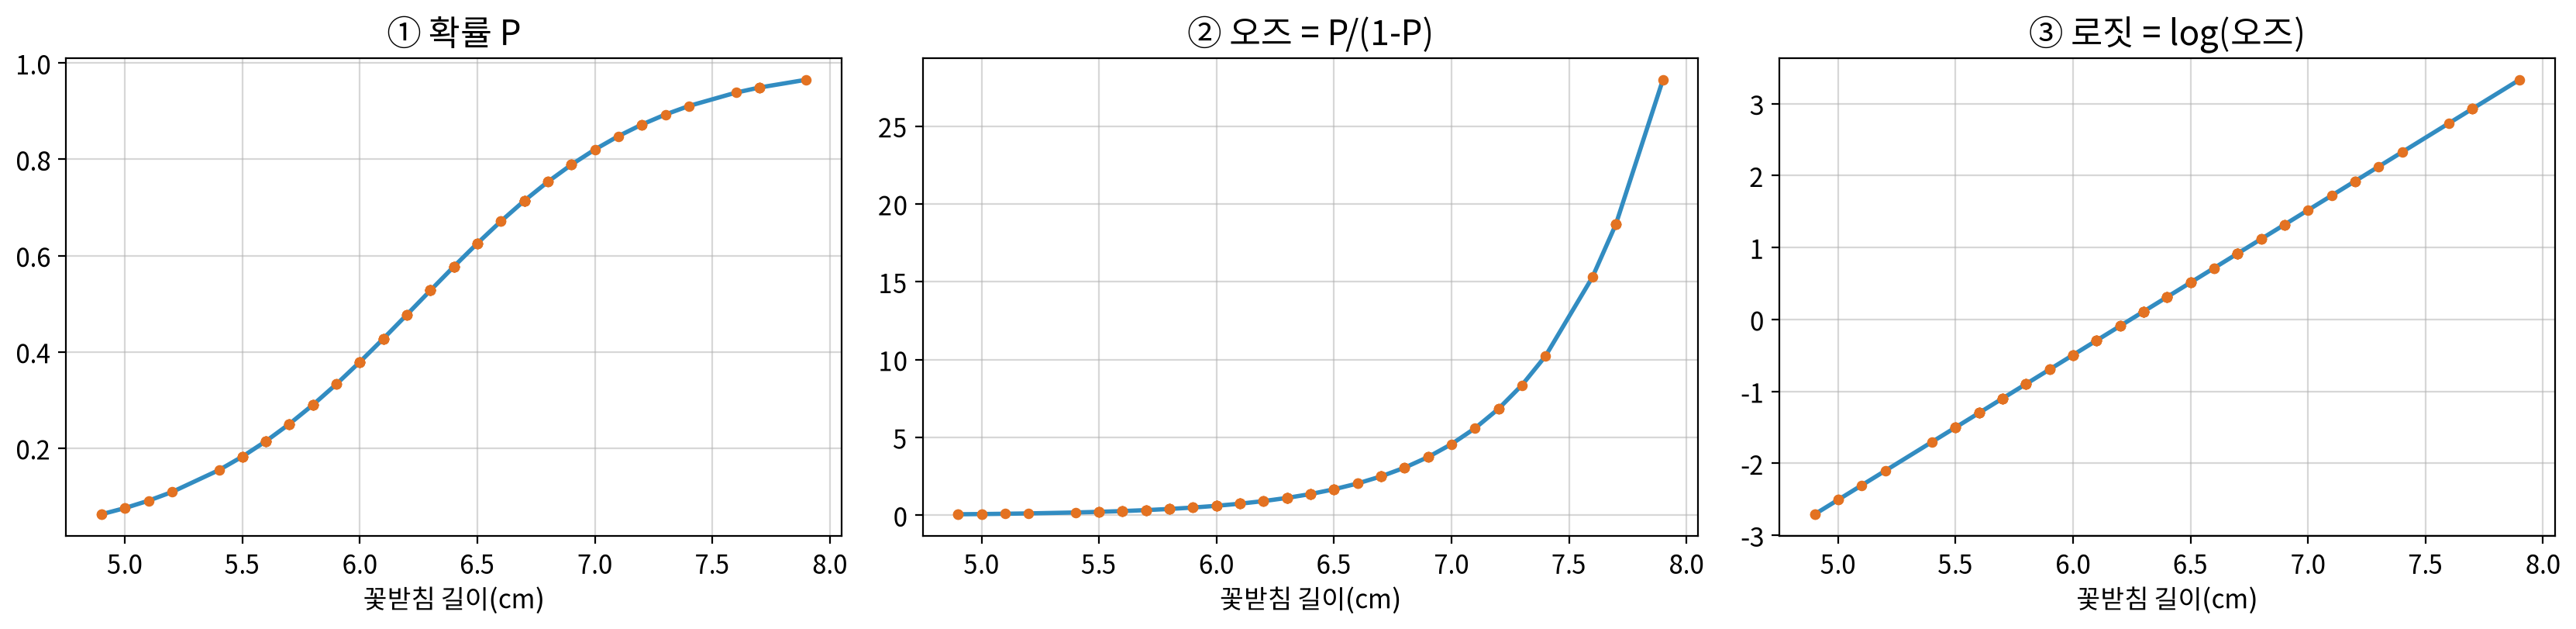

In [8]:
fig, ax = my_plot.init(rows=1, cols=3, width=560, height=440)

# 파란 선 = 모델 곡선, 주황 점 = 실제 관측된 꽃받침 길이 위치
ax[0].plot(x_real, p_real, color='#328CC1')
ax[0].scatter(x_real, p_real, color='#E37222', s=15, zorder=3)
ax[0].set_title('① 확률 P', fontsize=16)
ax[0].set_xlabel('꽃받침 길이(cm)')

ax[1].plot(x_real, odds_real, color='#328CC1')
ax[1].scatter(x_real, odds_real, color='#E37222', s=15, zorder=3)
ax[1].set_title('② 오즈 = P/(1-P)', fontsize=16)
ax[1].set_xlabel('꽃받침 길이(cm)')

ax[2].plot(x_real, logit_real, color='#328CC1')
ax[2].scatter(x_real, logit_real, color='#E37222', s=15, zorder=3)
ax[2].set_title('③ 로짓 = log(오즈)', fontsize=16)
ax[2].set_xlabel('꽃받침 길이(cm)')

my_plot.show()

> ① **확률**은 S자 곡선 → ② **오즈**는 폭발적으로 휘어지는 곡선 → ③ **로짓**은 완벽한 **직선**
>
> 즉 로지스틱회귀는 **로짓이라는 자를 써야 비로소 직선으로 보이는 모형**이다.
> 그래서 회귀계수 $B$는 "$x$가 1 증가할 때 **로짓**이 얼마나 증가하는가"를 뜻한다.

## #05. 오즈비(Odds Ratio)

### 1. 오즈비 = exp(B)

| 오즈비 | 의미 |
|---|---|
| **OR > 1** | 사건 발생 오즈를 **높이는** 요인 (증가 요인) |
| **OR = 1** | **영향 없음** |
| **OR < 1** | 사건 발생 오즈를 **낮추는** 요인 (감소 요인) |

In [9]:
B = fit1.params['Sepal_Length']
OR = np.exp(B)

print(f"회귀계수(B) : {B:.4f}")
print(f"오즈비(OR)  : {OR:.4f}")

회귀계수(B) : 2.0129
오즈비(OR)  : 7.4852


#### 💡인사이트

> 앞의 `check` 표에서 직접 계산한 **오즈 배율**과 정확히 같은 값이다.
> 즉 **오즈비는 계산으로 확인한 그 "일정한 배율"** 이다.

**해석**: 꽃받침 길이가 **1cm 증가**할 때, virginica일 **오즈가 약 7.49배**가 된다.

> ⚠️ **주의**: 오즈비 7.49는 **확률이 7.49배**가 된다는 뜻이 **아니다.**
> **오즈**가 7.49배가 된다는 뜻이다. (확률의 증가폭은 위치마다 다르다 — #02 참조)